<a href="https://colab.research.google.com/github/Razan445/IT326-Project/blob/main/Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('https://raw.githubusercontent.com/Razan445/IT326-Project/refs/heads/main/Dataset/Raw_dataset.csv')
raw_df = df.copy()

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [38]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
stat_summary = df[numeric_cols].describe().T

stat_summary['IQR'] = stat_summary['75%'] - stat_summary['25%']

print("--- Statistical and Five-Number Summaries ---")
display(stat_summary[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'IQR']])

--- Statistical and Five-Number Summaries ---


,count,mean,std,min,25%,50%,75%,max,IQR
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000,445.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000,1.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000,17.8750
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000,1.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000,0.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292,23.0896


### Statistical & Five-Number Summary Interpretation
- **`Age`:** Has a mean of ~29.7 years, a median (50%) of 28 years, and an IQR of 17.75 years, showing a relatively normal concentration around adults aged 20–38.
- **`Fare`:** Has a high standard deviation (std = 49.69) with a mean of 32.20 and a maximum of 512.32, which indicates a strongly right-skewed distribution with extreme high values.

In [39]:
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    'Missing Count': missing_count,
    'Percentage (%)': missing_percent
})

print("--- Missing Values Summary ---")
display(missing_table[missing_table['Missing Count'] > 0])

--- Missing Values Summary ---


,Missing Count,Percentage (%)
Age,177,19.865320
Cabin,687,77.104377
Embarked,2,0.224467


### Missing Values Analysis & Preprocessing Needs
- **`Cabin`:** Contains **687 missing values (77.10%)**. Due to this high missing rate, imputation is not recommended as it may introduce noise, suggesting the attribute should be dropped.
- **`Age`:** Contains **177 missing values (19.87%)**. Since Age is an important feature, it requires imputation using central metrics (e.g., median imputed by passenger class/gender).
- **`Embarked`:** Contains only **2 missing values (0.22%)**, which can easily be imputed using the mode (most frequent port).

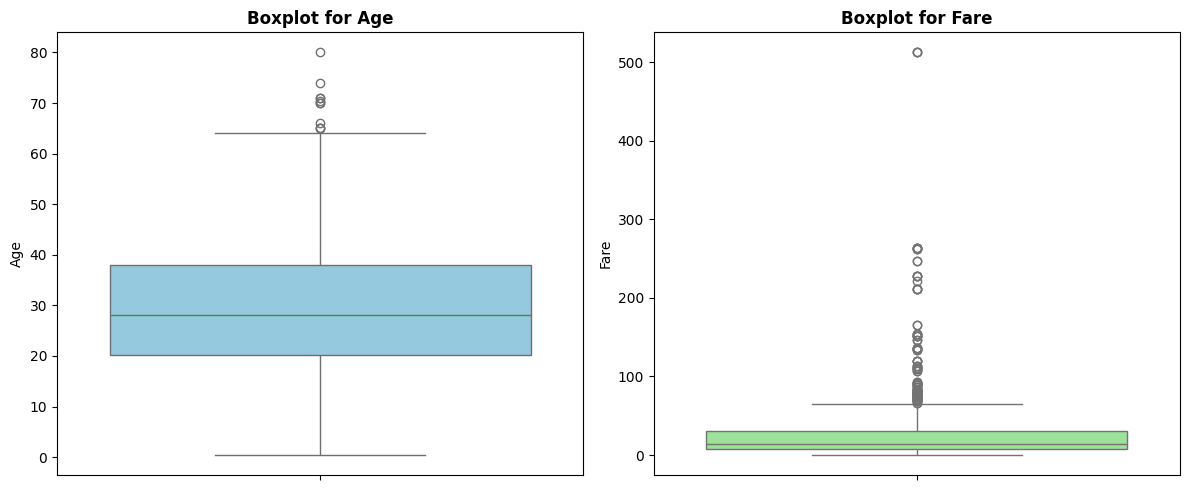

Age Outliers Count: 11 (Threshold: > 64.81)
Fare Outliers Count: 116 (Threshold: > 65.63)


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Outliers Extraction and Boxplots for Numeric Attributes
plt.figure(figsize=(12, 5))

# Boxplot for Age
plt.subplot(1, 2, 1)
sns.boxplot(y=df['Age'], color='skyblue')
plt.title('Boxplot for Age', fontsize=12, fontweight='bold')

# Boxplot for Fare
plt.subplot(1, 2, 2)
sns.boxplot(y=df['Fare'], color='lightgreen')
plt.title('Boxplot for Fare', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Detect Outliers programmatically using IQR
def detect_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    return len(outliers), lower, upper

age_outliers_cnt, age_low, age_high = detect_outliers_iqr(df['Age'].dropna())
fare_outliers_cnt, fare_low, fare_high = detect_outliers_iqr(df['Fare'].dropna())

print(f"Age Outliers Count: {age_outliers_cnt} (Threshold: > {age_high:.2f})")
print(f"Fare Outliers Count: {fare_outliers_cnt} (Threshold: > {fare_high:.2f})")

### Outliers Analysis & Need for Preprocessing
- **`Fare` Boxplot Explanation:** The plot indicates a severe presence of extreme upper outliers (116 data points above 65.63). This demonstrates that raw Fare values will skew distance-based machine learning algorithms. Thus, **normalization (such as Log Transformation or Min-Max / Standard Scaling)** is strongly needed in the preprocessing stage to handle noise and scale the data properly.
- **`Age` Boxplot Explanation:** Shows a small cluster of upper outliers (older passengers above 64.81 years). Since these are realistic historical values rather than errors, **discretization (binning ages into categorical groups)** or robust scaling can be utilized.

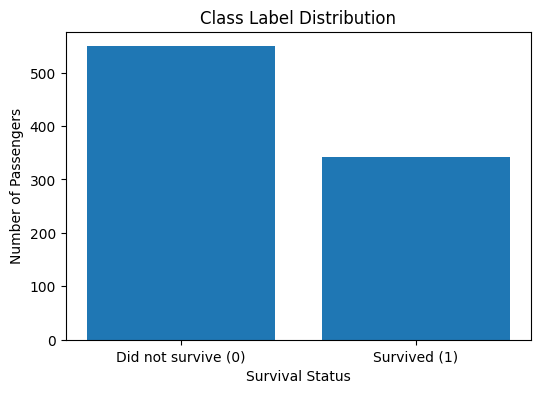

In [41]:
import matplotlib.pyplot as plt

survival_counts = df["Survived"].value_counts().sort_index()

plt.figure(figsize=(6, 4))

plt.bar(
    ["Did not survive (0)", "Survived (1)"],
    survival_counts.values
)

plt.title("Class Label Distribution")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")

plt.show()

Description:

The bar plot shows the distribution of the target variable, Survived, in the Titanic dataset. The dataset contains 549 passengers who did not survive (0) and 342 passengers who survived (1). This indicates that the class labels are imbalanced, as the number of passengers who did not survive is higher than the number of survivors. This imbalance should be considered during data preprocessing and when evaluating the performance of classification models.


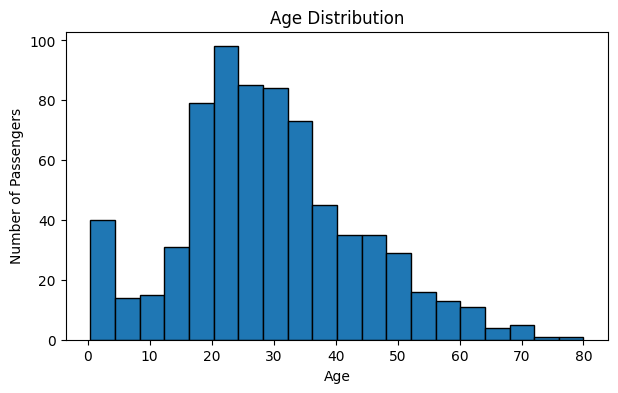

In [42]:
plt.figure(figsize=(7, 4))

plt.hist(df["Age"].dropna(), bins=20, edgecolor="black")

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

Description:

The histogram shows the distribution of passengers’ ages. Most passengers were between approximately 18 and 35 years old, with the highest frequency around the early twenties. The number of passengers generally decreases at older ages, and relatively few passengers were above 60 years old. The distribution is not uniform, with more passengers concentrated in the younger and middle-age ranges. This information helps us understand the distribution of the Age attribute and consider whether further preprocessing, such as discretization, would be useful for the data mining task.


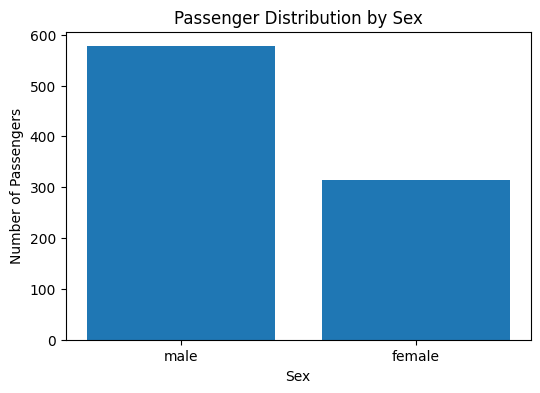

In [43]:
sex_counts = df["Sex"].value_counts()

plt.figure(figsize=(6, 4))

plt.bar(sex_counts.index, sex_counts.values)

plt.title("Passenger Distribution by Sex")
plt.xlabel("Sex")
plt.ylabel("Number of Passengers")

plt.show()

Description:

The bar plot shows the distribution of passengers by sex. The dataset contains approximately 577 male passengers and 314 female passengers, indicating that male passengers are more numerous than female passengers. The Sex attribute is categorical and nominal, so its values need to be converted into a suitable numerical representation before being used by algorithms that require numerical input. This observation supports considering categorical encoding during the preprocessing stage.


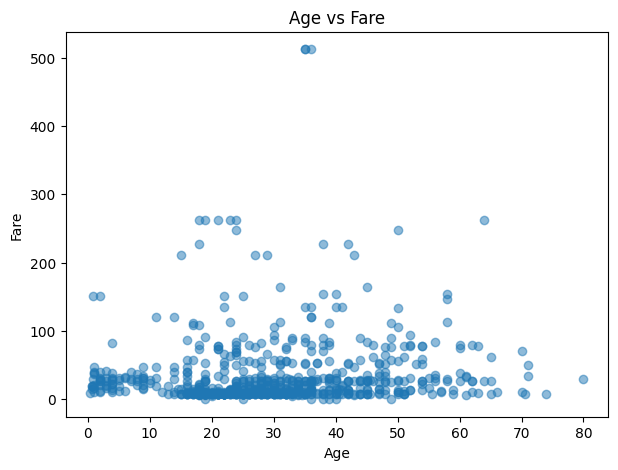

In [44]:
plt.figure(figsize=(7, 5))

plt.scatter(df["Age"], df["Fare"], alpha=0.5)

plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

Description:

The scatter plot illustrates the relationship between passengers’ ages and ticket fares. Most passengers paid fares below 50, across a wide range of ages. However, a small number of passengers paid much higher fares, including values close to 500. These extreme fare values indicate that the Fare attribute has a wide range and may contain potential outliers. This suggests that the fare distribution should be examined during preprocessing, and normalization or other suitable techniques may be considered if needed for the data mining algorithms.

In [45]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/Razan445/IT326-Project/refs/heads/main/Dataset/Raw_dataset.csv")


###Data Preprocessing – Technique 1: Cleaning & Noise Removal
In this section, missing values were handled and outliers were treated so the dataset is clean and ready for the next preprocessing steps.

In [46]:
# ===== 1. Snapshot of the raw dataset =====

print("Shape:", df.shape)

display(df.head(10))



# ===== 2. Work on a copy (raw stays untouched) =====

df_clean = df.copy()

print("\nMissing values before:\n", df_clean.isnull().sum())

print("\nDuplicates:", df_clean.duplicated().sum())



# ===== 3. Handle missing values =====

df_clean["Age"] = df_clean.groupby(["Sex", "Pclass"])["Age"].transform(lambda x: x.fillna(x.median()))



df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

df_clean = df_clean.drop(columns=["Cabin"])  # ~77% missing

print("\nMissing values after:", df_clean.isnull().sum().sum())



# ===== 4. Fare outliers (IQR + capping) =====

q1, q3 = df_clean["Fare"].quantile([0.25, 0.75])
max_limit = q3 + 1.5 * (q3 - q1)

print(f"\nFare outliers: {(df_clean['Fare'] > max_limit).sum()}")

print(f"Upper limit: {max_limit:.2f}")

print("Max Fare before:", df_clean["Fare"].max())

df_clean["Fare"] = df_clean["Fare"].clip(upper=max_limit)

print("Max Fare after:", df_clean["Fare"].max())



# ===== 5. Before / After summary =====

print("\nRows before:", df.shape[0], "| after:", df_clean.shape[0])

print("Columns before:", df.shape[1], "| after:", df_clean.shape[1])

display(df_clean.head(10))



# ===== 6. Save for Student 4 =====

df_clean.to_csv("cleaned_step1.csv", index=False)

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C



Missing values before:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Duplicates: 0

Missing values after: 0

Fare outliers: 116
Upper limit: 65.63
Max Fare before: 512.3292
Max Fare after: 65.6344

Rows before: 891 | after: 891
Columns before: 12 | after: 11


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,65.6344,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",male,25.0,0,0,330877,8.4583,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C


###Justification
**Why:** The raw dataset contained missing values in Age (177), Cabin (687) and Embarked (2). Decision Tree and K-means in scikit-learn cannot handle missing values. The Fare column also had 116 outliers (max = 512.33) that distort distance-based clustering such as K-means.

**How:**

* **Age:** filled with the median grouped by Sex and Pclass, because age differs across these groups, which makes it more accurate than a global median.

* **Embarked:** filled with the mode since only 2 values were missing.

* **Cabin:** dropped because about 77% of its values were missing, and imputing would add noise.

* **Fare:** outliers were detected using the IQR rule and capped at Q3 + 1.5×IQR (= 65.63) instead of deleting rows, to keep all records.

**Columns affected:** Age, Cabin, Embarked, Fare

**Result:** Missing values dropped from 866 to 0. All 891 rows were preserved. The maximum Fare decreased from 512.33 to 65.63, giving a less skewed distribution that is ready for the next preprocessing steps.

###Justification
Why: The raw dataset contained missing values in Age (177), Cabin (687) and Embarked (2). Decision Tree and K-means in scikit-learn cannot handle missing values. The Fare column also had 116 outliers (max = 512.33) that distort distance-based clustering such as K-means.

How:

Age: filled with the median grouped by Sex and Pclass, because age differs across these groups, which makes it more accurate than a global median.

Embarked: filled with the mode since only 2 values were missing.

Cabin: dropped because about 77% of its values were missing, and imputing would add noise.

Fare: outliers were detected using the IQR rule and capped at Q3 + 1.5×IQR (= 65.63) instead of deleting rows, to keep all records.

Columns affected: Age, Cabin, Embarked, Fare

Result: Missing values dropped from 866 to 0. All 891 rows were preserved. The maximum Fare decreased from 512.33 to 65.63, giving a less skewed distribution that is ready for the next preprocessing steps.

###Data Preprocessing — Technique 2: Encoding
Why: K-Means and other machine learning algorithms cannot work with text (categorical) data — everything must be numeric before applying Classification or Clustering. The columns Sex and Embarked are text-based, so they need to be converted to numbers.

How and on which attributes:

Sex: has only 2 categories (male/female), so we used Label Encoding (male=0, female=1).
Embarked: has 3 categories (S, C, Q) with no logical order between them, so we used One-Hot Encoding to avoid implying a false ranking between the categories.
Result: After encoding, all columns became fully numeric, making the dataset ready for applying classification and clustering algorithms without errors, and without any bias from an artificial relationship between the port categories.

In [47]:
import pandas as pd

df_clean = pd.read_csv("cleaned_step1.csv")

print(df_clean[['Sex', 'Embarked']].head())

df_clean['Sex'] = df_clean['Sex'].map({'male': 0, 'female': 1})

df_clean = pd.get_dummies(df_clean, columns=['Embarked'], prefix='Embarked')

print(df_clean.head())

df_clean.to_csv("encoded_step2.csv", index=False)

      Sex Embarked
0    male        S
1  female        C
2  female        S
3  female        S
4    male        S
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    0  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    1  38.0      1      0   
2                             Heikkinen, Miss. Laina    1  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    1  35.0      1      0   
4                           Allen, Mr. William Henry    0  35.0      0      0   

             Ticket     Fare  Embarked_C  Embarked_Q  Embarked_S  
0         A/5 21171   7.2500       False       False        True  
1          PC 17599  65.6344        True       F


# Technique 3: Normalization
**Why**: Distance-based algorithms (like K-Means clustering which we will use in Phase 3) are highly sensitive to the scale of data. Features with larger ranges (like Fare) will dominate the distance calculations.

**How and on which attributes:** We applied MinMaxScaler to scale numeric attributes (Age, Fare, SibSp, Parch) to a standard range of [0, 1].

**Result:** Normalization improved the dataset by bringing all numeric attributes to an equal scale [0, 1]. This prevents attributes with inherently larger ranges (like Fare) from outweighing smaller ones (like SibSp or Parch), ensuring unbiased and highly accurate distance calculations for algorithms like K-Means.

In [48]:
from sklearn.preprocessing import MinMaxScaler

cols_to_normalize = ['Age', 'Fare', 'SibSp', 'Parch']
scaler = MinMaxScaler()
df_clean[cols_to_normalize] = scaler.fit_transform(df_clean[cols_to_normalize])


print("Snapshot of preprocessed dataset:")
display(df_clean.head())

df_clean.to_csv('Preprocessed_dataset.csv', index=False)


Snapshot of preprocessed dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,0.271174,0.125,0.0,A/5 21171,0.110460,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0.472229,0.125,0.0,PC 17599,1.000000,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,0.321438,0.000,0.0,STON/O2. 3101282,0.120745,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0.434531,0.125,0.0,113803,0.809027,False,False,True
4,5,0,3,"Allen, Mr. William Henry",0,0.434531,0.000,0.0,373450,0.122649,False,False,True
